In [11]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df=sns.load_dataset('iris')

In [13]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])


In [15]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
df = df[['sepal_length','petal_length','species']]


In [17]:
df.head()


,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [18]:

X = df.iloc[:,0:2]
y = df.iloc[:,-1]


In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [21]:

clf = LogisticRegression()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

y_prob = clf.predict_proba(X_test)

print("Predictions:", y_pred)
print("Probabilities:", y_prob)

Predictions: [0 0 2 0 0 2 0 2 2 0 0 0 0 0 1 1 0 1 2 1 2 1 2 1 1 0 0 2 0 2]
Probabilities: [[9.74711228e-01 2.52885799e-02 1.92154549e-07]
 [9.67530665e-01 3.24689802e-02 3.54482443e-07]
 [6.44548122e-04 3.25623501e-01 6.73731950e-01]
 [9.71813740e-01 2.81860658e-02 1.94400385e-07]
 [9.04965961e-01 9.50300260e-02 4.01349554e-06]
 [5.71107737e-06 5.21487693e-02 9.47845520e-01]
 [9.48544863e-01 5.14544719e-02 6.65000437e-07]
 [5.99051837e-06 4.13983512e-02 9.58595658e-01]
 [2.04825423e-05 7.15792595e-02 9.28400258e-01]
 [9.71813740e-01 2.81860658e-02 1.94400385e-07]
 [9.52771269e-01 4.72283632e-02 3.67372374e-07]
 [9.82373374e-01 1.76265237e-02 1.02696728e-07]
 [9.80988828e-01 1.90111141e-02 5.76510142e-08]
 [9.19382476e-01 8.06162905e-02 1.23337272e-06]
 [4.67035973e-03 7.70261121e-01 2.25068519e-01]
 [2.66126697e-03 7.50134092e-01 2.47204641e-01]
 [9.81382041e-01 1.86178560e-02 1.03344608e-07]
 [1.37317830e-02 8.85408812e-01 1.00859405e-01]
 [1.09353880e-05 5.84248222e-02 9.41564242e-01

In [22]:
y_pred = clf.predict(X_test)


In [23]:
print(accuracy_score(y_test,y_pred))


0.9666666666666667


In [24]:
pd.DataFrame(confusion_matrix(y_test,y_pred))


,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [25]:
# prediction
query = np.array([[3.4,2.7]])
clf.predict_proba(query)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [26]:
clf.predict(query)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


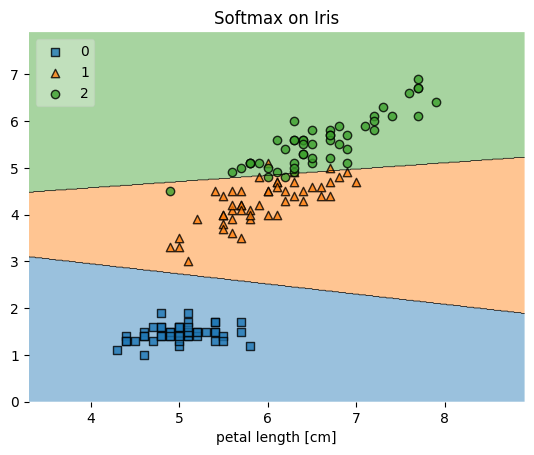

In [27]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X.values, y.values, clf, legend=2)

# Adding axes annotations
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()